# EXP8 — Fair vs conservative $q_{\text{std}}$ for extremes

$q_{\text{std}}$ is the per-basin standardisation scale used throughout the Ch3 pipeline (the variance head trains on $z=r/q_{\text{std}}$, and the decomposition un-standardises by the same factor). The shipped value is a **year-round** scale: the standard deviation of training-period (1980–2005) runoff over *all* days.

That is the **conservative** choice for evaluating extremes, and it is conservative in a specific direction. A snowmelt basin's year-round variability is dominated by the seasonal cycle, so a June flood is being judged against a scale that includes every quiet winter day. Whether that flatters or penalises the extremes depends on the basin, and it is not obvious a priori.

The **fair** alternative asks: what is normal *for this basin at this time of year*? Same recipe, same training period, but restricted to the calendar window the event occupies.

| set | fair $q_{\text{std}}$ definition |
|---|---|
| 2021 heat dome | training days with (month, day) in 1 Jun – 31 Jul |
| 2021 AR flood | training days with (month, day) in 20 Oct – 10 Dec |
| test-extremes (top flow decile) | **month-matched** per basin-day — that set spans 2,705 dates across the calendar, so no single window applies |

Both arms use one recipe, so the contrast isolates seasonality rather than mixing in a recipe difference.

**Recipe, verified against the contract.** `np.nanstd(runoff_mm_per_day[train], axis=0, ddof=0)` — reproduces `q_std.csv` / `basin_stds` to $<10^{-3}$ for all 269 basins (correlation 1.000000). **No floor is applied.** Note that `results_MVE/meta.json` describes $q_{\text{std}}$ as "floored at 1.0"; the shipped vector is not floored (min 0.0108, no value exactly 1.0), so that line in the contract is inaccurate and the floor is *not* reproduced here.

*Everything below is diagnostic. No figure here is a paper figure.*

In [1]:
import sys, json, pathlib
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p/"src"/"config.py").exists()), None)
if _root is None: raise RuntimeError(f"project root not found from {pathlib.Path.cwd()}")
if str(_root) not in sys.path: sys.path.insert(0, str(_root))
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, OUTPUT_STATIC_ATTR
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
stations = pd.read_csv(R/"q_std.csv")["station_id"].astype(str).to_numpy()
qs_cons  = pd.read_csv(R/"q_std.csv")["q_std"].to_numpy()          # year-round, as shipped
y = np.load(R/"y_obs_mm.npy"); valid = np.load(R/"valid_mask_ald.npy")
mu = np.load(VAR/"predictive.npz")["mu_hat"]
test = (split=="test"); r_all = y - mu

# ---- raw observations on the SAME station axis, converted to mm/day ----
at = pd.read_csv(OUTPUT_STATIC_ATTR, index_col=0); at.index = at.index.astype(str)
obs = pd.read_csv(PROCESSED_DATA_DIR/"combined_streamflow.csv", index_col=0,
                  parse_dates=True).reindex(columns=stations)
mm = obs.values * (86.4/at.reindex(stations)["basin_area_km2"].values)
o_tr  = (obs.index.year>=1980) & (obs.index.year<=2005)
o_md  = obs.index.month.to_numpy()*100 + obs.index.day.to_numpy()   # e.g. 20 Oct -> 1020
o_mon = obs.index.month.to_numpy()

# ---- verify the recipe reproduces the shipped scale before trusting the fair one ----
chk = np.nanstd(mm[o_tr], axis=0, ddof=0)
assert np.allclose(chk, qs_cons, atol=1e-3), "recipe does not reproduce q_std.csv"
print(f"recipe check: reproduces q_std.csv for {int((np.abs(chk-qs_cons)<1e-3).sum())}/269 basins "
      f"(max diff {np.abs(chk-qs_cons).max():.2e}, corr {np.corrcoef(chk,qs_cons)[0,1]:.6f})")
print(f"no floor applied: min q_std = {qs_cons.min():.4f}, values exactly 1.0 = {int((qs_cons==1.0).sum())}")

def qstd_window(m0,d0,m1,d1):
    """Same recipe, restricted to a calendar window (training years only)."""
    w = (o_md >= m0*100+d0) & (o_md <= m1*100+d1)          # window within a calendar year
    return np.nanstd(mm[w & o_tr], axis=0, ddof=0), int((w & o_tr).sum())

HDW, ARW_DATES = (6,1,7,31), (10,20,12,10)
qs_hd, n_hd = qstd_window(*HDW)
qs_ar, n_ar = qstd_window(*ARW_DATES)
with np.errstate(invalid="ignore"):                      # basins with no data in a month -> NaN
    import warnings; warnings.filterwarnings("ignore", message="Degrees of freedom")
    qs_mon = np.stack([np.nanstd(mm[o_tr & (o_mon==k)], axis=0, ddof=0) for k in range(1,13)])  # 12 x 269
print(f"fair q_std: heat-dome window uses {n_hd:,} training basin-days/basin-window; "
      f"AR window {n_ar:,}; month-matched uses ~{int(o_tr.sum()/12):,} per month")
# A narrow seasonal window can be degenerate: basins that are frozen / near-zero all autumn
# have (near-)zero variance there. With no floor those give an infinite z, so they are counted
# and dropped rather than silently propagated.
EPS = 1e-6
for nm, q in (("heat dome", qs_hd), ("AR flood", qs_ar), ("month-matched", qs_mon.ravel())):
    q = np.asarray(q)
    print(f"  fair q_std {nm:14s}: min {np.nanmin(q):.4f}  |  zero/degenerate (<{EPS}) "
          f"{int(np.nansum(q < EPS))}  |  NaN (no training data in window) {int(np.isnan(q).sum())}")

recipe check: reproduces q_std.csv for 269/269 basins (max diff 2.74e-05, corr 1.000000)
no floor applied: min q_std = 0.0108, values exactly 1.0 = 0
fair q_std: heat-dome window uses 1,586 training basin-days/basin-window; AR window 1,352; month-matched uses ~791 per month
  fair q_std heat dome     : min 0.0002  |  zero/degenerate (<1e-06) 0  |  NaN (no training data in window) 0
  fair q_std AR flood      : min 0.0000  |  zero/degenerate (<1e-06) 0  |  NaN (no training data in window) 0
  fair q_std month-matched : min 0.0000  |  zero/degenerate (<1e-06) 11  |  NaN (no training data in window) 154


## The three evaluation sets

Same definitions used elsewhere in the project. The AR block is restricted to the 74 basins **west of $-121^\circ$** — it was a Lower Mainland / SW-BC event, and scoring it domain-wide dilutes it with ~200 basins in ordinary autumn conditions. The heat dome stays domain-wide (forcing selection retains 264/269, so restricting is pointless).

In [2]:
lon = at.reindex(stations)["longitude"].values
AR_WEST = (lon < -121) & np.isfinite(lon)
HD_DAYS = (dates>=pd.Timestamp("2021-06-01")) & (dates<=pd.Timestamp("2021-07-31"))
AR_DAYS = (dates>=pd.Timestamp("2021-10-20")) & (dates<=pd.Timestamp("2021-12-10"))
pct = pd.DataFrame(np.where(test[:,None]&valid, y, np.nan)).rank(pct=True).to_numpy()
bi  = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
tb  = (test[:,None]&valid) & np.isfinite(pct)
d_mon = dates.month.to_numpy()

SETS = {
 "test-extremes":  dict(mask=tb & (bi==9),                                    fair=("month", None)),
 "2021 heat dome": dict(mask=(test&HD_DAYS)[:,None]&valid,                     fair=("basin", qs_hd)),
 "2021 AR flood":  dict(mask=((test&AR_DAYS)[:,None]&valid)&AR_WEST[None,:],   fair=("basin", qs_ar)),
}
def z_pair(spec):
    """Standardised residual under the conservative and the fair scale, for one set.
    Basin-days whose fair scale is degenerate (<EPS or NaN) are dropped, and counted."""
    m = spec["mask"]; ii, jj = np.where(m)
    kind, arr = spec["fair"]
    qf = qs_mon[d_mon[ii]-1, jj] if kind=="month" else arr[jj]
    ok = np.isfinite(qf) & (qf >= EPS)
    if (~ok).any():
        print(f"    dropped {int((~ok).sum()):,} of {len(ok):,} basin-days with a degenerate fair scale")
    ii, jj, qf = ii[ok], jj[ok], qf[ok]
    r = r_all[ii, jj]
    return r/qs_cons[jj], r/qf, qf, qs_cons[jj], jj

Z = {}
for k, v in SETS.items():
    print(f"  {k}:"); Z[k] = z_pair(v)
print(f"{'set':16s} {'basin-days':>11s} {'basins':>7s} | {'median |z| cons':>16s} {'fair':>8s} | "
      f"{'q_std ratio fair/cons: median':>30s}")
for k,(zc,zf,qf,qc,jj) in Z.items():
    print(f"{k:16s} {len(zc):11,d} {len(np.unique(jj)):7d} | {np.median(np.abs(zc)):16.3f} "
          f"{np.median(np.abs(zf)):8.3f} | {np.median(qf/qc):30.3f}")

  test-extremes:
    dropped 5 of 87,930 basin-days with a degenerate fair scale
  2021 heat dome:
  2021 AR flood:
set               basin-days  basins |  median |z| cons     fair |  q_std ratio fair/cons: median
test-extremes         87,925     269 |            0.574    0.532 |                          1.124
2021 heat dome        16,409     269 |            0.131    0.125 |                          1.106
2021 AR flood          3,843      74 |            0.159    0.407 |                          0.386


## 1. How much does the scale itself change?

Ratio of fair to conservative $q_{\text{std}}$, per basin-day in each set. Above 1 means the seasonally-matched scale is *larger* — the period is more variable than the basin's year-round average, so the conservative scale understates what is normal then, and standardised residuals computed with it are inflated. Below 1 is the reverse.

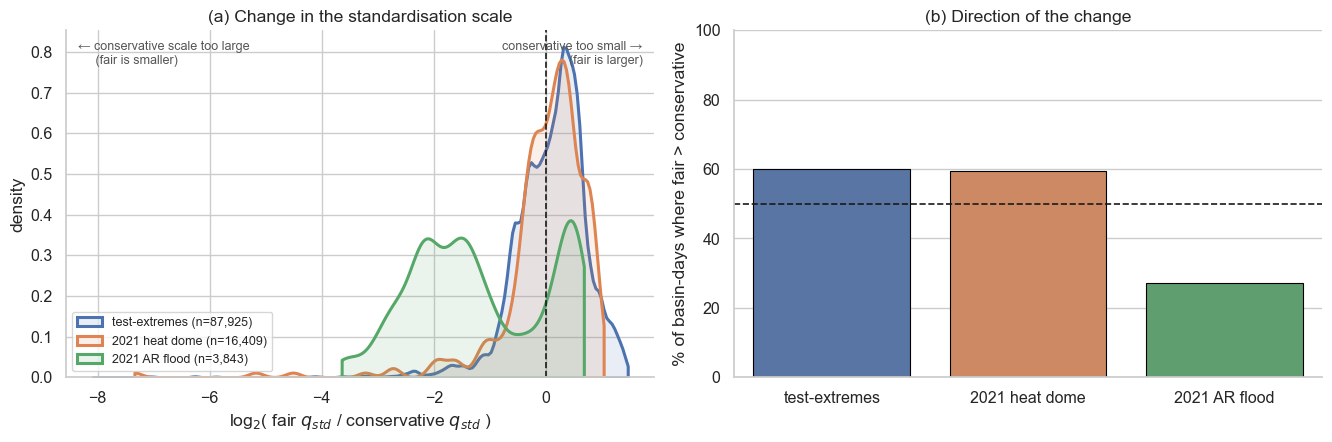

           set  basins  basin_days  q_cons_med  q_fair_med  ratio_med  ratio_q25  ratio_q75  %_fair_larger
 test-extremes     269       87925       1.448       1.616      1.124      0.820      1.402           59.9
2021 heat dome     269       16409       1.305       1.615      1.106      0.830      1.345           59.5
 2021 AR flood      74        3843       2.646       0.914      0.386      0.227      1.079           27.1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
pal = {"test-extremes":"#4c72b0", "2021 heat dome":"#dd8452", "2021 AR flood":"#55a868"}
for k,(zc,zf,qf,qc,jj) in Z.items():
    ratio = qf/qc; ratio = ratio[np.isfinite(ratio) & (ratio>0)]
    sns.kdeplot(np.log2(ratio), ax=axes[0], label=f"{k} (n={len(ratio):,})",
                color=pal[k], lw=2.2, fill=True, alpha=.12, cut=0)
axes[0].axvline(0, color="k", ls="--", lw=1.2)
axes[0].set(xlabel="log$_2$( fair $q_{std}$ / conservative $q_{std}$ )",
            ylabel="density", title="(a) Change in the standardisation scale")
axes[0].text(.02,.97,"← conservative scale too large\n     (fair is smaller)", transform=axes[0].transAxes,
             va="top", ha="left", fontsize=9, color="#555")
axes[0].text(.98,.97,"conservative too small →\n(fair is larger)", transform=axes[0].transAxes,
             va="top", ha="right", fontsize=9, color="#555")
axes[0].legend(fontsize=9)

rows=[]
for k,(zc,zf,qf,qc,jj) in Z.items():
    u=np.unique(jj)
    rows.append({"set":k, "basins":len(u), "basin_days":len(zc),
                 "q_cons_med":round(float(np.median(qc)),3),
                 "q_fair_med":round(float(np.median(qf)),3),
                 "ratio_med":round(float(np.median(qf/qc)),3),
                 "ratio_q25":round(float(np.percentile(qf/qc,25)),3),
                 "ratio_q75":round(float(np.percentile(qf/qc,75)),3),
                 "%_fair_larger":round(100*float(np.mean(qf>qc)),1)})
tab=pd.DataFrame(rows)
sns.barplot(data=tab, x="set", y="%_fair_larger", hue="set", legend=False, ax=axes[1],
            palette=pal, edgecolor="black", linewidth=.8)
axes[1].axhline(50, color="k", ls="--", lw=1.2)
axes[1].set(ylabel="% of basin-days where fair > conservative", xlabel="",
            title="(b) Direction of the change", ylim=(0,100))
sns.despine(fig); plt.tight_layout(); plt.show()
print(tab.to_string(index=False))

## 2. What it does to the standardised residual

$z = (y-\hat{\mu})/q_{\text{std}}$ under each scale. This is the quantity the variance head is trained on, so the choice of scale propagates directly into what the head is asked to predict. A KDE on the raw values is dominated by a handful of enormous $z$ (no floor on $q_{\text{std}}$, and some basins have year-round scales near 0.01 mm day$^{-1}$), so the display is clipped and the clipped fraction reported.

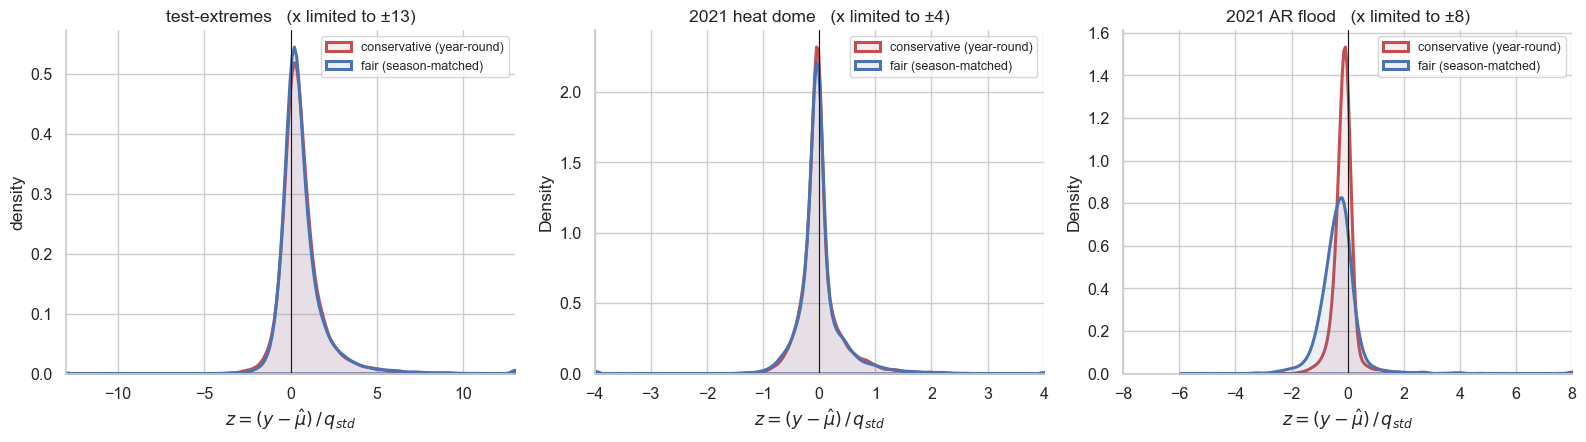

           set                     scale     n  median_|z|   IQR_|z|  p99_|z|  max_|z|  %_beyond_panel
 test-extremes conservative (year-round) 87925       0.574 0.25-1.15     7.22     85.9            0.25
 test-extremes     fair (season-matched) 87925       0.532 0.23-1.09     8.57    516.0            0.44
2021 heat dome conservative (year-round) 16409       0.131 0.05-0.32     1.79      7.6            0.15
2021 heat dome     fair (season-matched) 16409       0.125 0.05-0.33     2.26     24.5            0.48
 2021 AR flood conservative (year-round)  3843       0.159 0.07-0.33     3.96     29.9            0.36
 2021 AR flood     fair (season-matched)  3843       0.407 0.18-0.74     3.45     27.8            0.18

KDE drawn on <= 40,000 sampled basin-days per curve (seed 0); medians/IQR/p99/max use ALL basin-days.
A ratio change in q_std is a pure rescaling of z, so the fair/conservative contrast is a
horizontal stretch of the same shape -- the medians in the table are the cleaner read.


In [4]:
# Per-panel x-limits: the three sets differ ~5x in spread, so one shared window either
# clips the widest or collapses the narrowest into a spike. Limits are set from each set's
# own 99.5th percentile, and the clipped fraction is reported.
rng = np.random.default_rng(0); SUB = 40_000
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
summ=[]
for ax,(k,(zc,zf,qf,qc,jj)) in zip(axes, Z.items()):
    zc, zf = zc[np.isfinite(zc)], zf[np.isfinite(zf)]
    lim = float(np.ceil(max(np.percentile(np.abs(zc),99.5), np.percentile(np.abs(zf),99.5))))
    for lbl,z,col in (("conservative (year-round)",zc,"#c44e52"),
                      ("fair (season-matched)",   zf,"#4c72b0")):
        s = z if len(z)<=SUB else rng.choice(z, SUB, replace=False)
        sns.kdeplot(np.clip(s,-lim,lim), ax=ax, label=lbl, color=col, lw=2.2,
                    fill=True, alpha=.10, cut=0)
        summ.append({"set":k,"scale":lbl,"n":len(z),
                     "median_|z|":round(float(np.median(np.abs(z))),3),
                     "IQR_|z|":f"{np.percentile(np.abs(z),25):.2f}-{np.percentile(np.abs(z),75):.2f}",
                     "p99_|z|":round(float(np.percentile(np.abs(z),99)),2),
                     "max_|z|":round(float(np.abs(z).max()),1),
                     f"%_beyond_panel":round(100*float(np.mean(np.abs(z)>lim)),2)})
    ax.axvline(0, color="k", lw=.8)
    ax.set(title=f"{k}   (x limited to ±{lim:g})",
           xlabel="$z = (y-\\hat{\\mu})\\,/\\,q_{std}$", xlim=(-lim,lim))
    ax.legend(fontsize=9)
axes[0].set_ylabel("density")
sns.despine(fig); plt.tight_layout(); plt.show()
print(pd.DataFrame(summ).to_string(index=False))
print(f"\nKDE drawn on <= {SUB:,} sampled basin-days per curve (seed 0); medians/IQR/p99/max use ALL basin-days."
      "\nA ratio change in q_std is a pure rescaling of z, so the fair/conservative contrast is a"
      "\nhorizontal stretch of the same shape -- the medians in the table are the cleaner read.")

## Reading it

The direction of the correction is **opposite for the two events**, and that is the finding:

- **Test-extremes and the heat dome** occur in each basin's *high*-variability season, so the seasonally matched scale is slightly **larger** than the year-round one (median ratio 1.12 and 1.11; fair is larger for ~60% of basin-days). Judging them against year-round variability therefore mildly *overstates* how anomalous they are, and $|z|$ falls ~8% under the fair scale.
- **The AR flood is the reverse, and by a lot.** Its fair scale is **2.6× smaller** (median ratio 0.39; fair is larger for only 27% of basin-days), so median $|z|$ rises from 0.16 to 0.41. For most basins in that block, late October to early December is a *low*-variability period, and the year-round scale substantially **understates** how anomalous the AR residuals are.

That last point is worth pausing on, because it is not what a Lower Mainland flood story would predict. Rain-dominated coastal basins peak in autumn and should be *most* variable then. A median ratio of 0.39 says the typical basin west of $-121^\circ$ is snowmelt-dominated — quiet in late autumn, peaking in June — so the $-121^\circ$ cut is mixing rain-flashy Lower Mainland basins with Coast Mountain snowmelt basins that were not really participating in this event. That is independent evidence that the longitude threshold is a crude proxy for the corridor, and it points at the seasonal signature as a sharper basis for defining the block than geography alone.

## Which scale should the variance head use?

The head learns $z = r/q_{\text{std}}$ and the decomposition un-standardises by the same factor, so this choice propagates into the target. Neither scale is unconditionally right:

- **Conservative** is estimated from ~9,500 training days per basin, so it is stable, but it is not the like-for-like comparison for a seasonal event, and it mis-scales in opposite directions for the two events above.
- **Fair** is the like-for-like comparison but rests on ~1,300–1,600 training days per basin-window (~790 per basin-month), is noisier, and with no floor can be degenerate for basins that are near-zero in a given season — those basin-days are counted and dropped above rather than allowed to produce an infinite $z$.

A defensible middle course, if this matters downstream, is a seasonally varying scale with a floor tied to the basin's year-round value (e.g. $\max(q_{\text{season}},\,\alpha\,q_{\text{year}})$), which keeps the like-for-like comparison while bounding the degenerate cases. That is a methods decision, and belongs in the log before it is implemented rather than after.

*Caveats.* Training period only (1980–2005), so no test information enters either scale. No floor, matching the shipped vector rather than the `meta.json` description — **the contract says "floored at 1.0" and the shipped vector is not floored (min 0.0108, no value exactly 1.0); that line should be corrected.** The month-matched variant for test-extremes uses whole calendar months, which for the two events would straddle their window edges, which is why the events use their exact windows.